In [ ]:
# Mount Drive
from google.colab import drive
drive.mount('/content/drive')

PROJECT_DIR = '/content/drive/MyDrive/PolicySentimentProject'

# Install scraping library
!pip install -q newspaper3k tqdm lxml_html_clean

import pandas as pd
import numpy as np
from newspaper import Article
from tqdm import tqdm
from transformers import pipeline
import matplotlib.pyplot as plt
import time
import os

print("✅ Extension setup complete!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Extension setup complete!


In [ ]:
# Loading EXISTING processed data
df_policy = pd.read_csv(
    f'{PROJECT_DIR}/data/policy_sentiment_complete.csv',
    parse_dates=['Date']
)

print(f"✅ Loaded {len(df_policy)} policy headlines")
print(f"Columns: {df_policy.columns.tolist()}")

# Check if URL column exists
if 'URL' in df_policy.columns:
    print(f"✅ URL column found! Ready for scraping")
    print(f"Sample URL: {df_policy['URL'].iloc[0]}")
else:
    print("❌ No URL column found. Check your saved data.")

✅ Loaded 40423 policy headlines
Columns: ['Date', 'Title', 'URL', 'sentiment', 'confidence', 'text', 'flair_compound', 'flair_label', 'policy_topics', 'num_topics', 'primary_topic', 'entities', 'bert_topic_id', 'bert_topic_prob', 'finbert_label', 'finbert_confidence', 'finbert_compound', 'vader_compound', 'vader_label', 'aspects', 'finbert_polarity', 'flair_polarity', 'vader_polarity', 'flair_label_clean', 'finbert_label_clean']
✅ URL column found! Ready for scraping
Sample URL: http://www.financialexpress.com/industry/banking-finance/in-2016-rbis-actions-changed-the-fortune-of-indian-rupee/492959/


In [ ]:
# Instead of scraping ALL 30,000 URLs
# Just scraping a random 2000 sample

import concurrent.futures # Import concurrent.futures

SAMPLE_SIZE = 2000
SAVE_PATH = f'{PROJECT_DIR}/data/extension_scraped.csv' # Define SAVE_PATH

# Define safe_scrape function
def safe_scrape(url):
    try:
        article = Article(str(url))
        article.download()
        article.parse()
        return article.text if len(article.text) > 50 else None
    except:
        return None

if 'full_text' not in df_policy.columns:
    df_policy['full_text'] = None

# Get unscrapped rows
mask = df_policy['full_text'].isna()
remaining = df_policy[mask].index.tolist()

# Take random sample
import random
sample = random.sample(remaining, min(SAMPLE_SIZE, len(remaining)))
sample_urls = [df_policy.at[idx, 'URL'] for idx in sample]

print(f"Scraping random sample of {len(sample)} URLs...")

with concurrent.futures.ThreadPoolExecutor(max_workers=10) as executor:
    futures = {executor.submit(safe_scrape, url): idx
               for idx, url in zip(sample, sample_urls)}

    for future in tqdm(concurrent.futures.as_completed(futures),
                      total=len(futures), desc="Scraping"):
        idx = futures[future]
        df_policy.at[idx, 'full_text'] = future.result()

# Save
df_policy.to_csv(SAVE_PATH, index=False)
done = df_policy['full_text'].notna().sum()
print(f"\n✅ Scraped {done} articles successfully!")

Scraping random sample of 2000 URLs...


Scraping: 100%|██████████| 2000/2000 [09:20<00:00,  3.57it/s]



✅ Scraped 1945 articles successfully!


In [ ]:
# Use full text where available, headline where not
df_policy['analysis_text'] = df_policy.apply(
    lambda row: row['full_text']
    if pd.notna(row['full_text']) and len(str(row['full_text'])) > 50
    else row['Title'],
    axis=1
)

# Filter only successfully scraped articles for comparison
df_scraped = df_policy[df_policy['full_text'].notna()].copy()
print(f"✅ Articles with full text for comparison: {len(df_scraped)}")

✅ Articles with full text for comparison: 1945


In [ ]:
from transformers import pipeline
import torch

device = 0 if torch.cuda.is_available() else -1
finbert = pipeline("sentiment-analysis", model="ProsusAI/finbert", device=device)

def get_fulltext_sentiment(text, max_length=512):
    """Handle long articles by chunking and averaging"""
    text = str(text).strip()

    if len(text) <= max_length:
        result = finbert(text[:max_length])[0]
        label_map = {'positive': 1, 'neutral': 0, 'negative': -1}
        return label_map[result['label'].lower()] * result['score']

    # Split long text into chunks
    chunks = [text[i:i+max_length] for i in range(0, len(text), max_length)]
    chunks = chunks[:5]  # Limit to first 5 chunks

    scores = []
    for chunk in chunks:
        if len(chunk.strip()) > 30:
            result = finbert(chunk)[0]
            label_map = {'positive': 1, 'neutral': 0, 'negative': -1}
            score = label_map[result['label'].lower()] * result['score']
            scores.append(score)

    return sum(scores) / len(scores) if scores else 0

print(f"Running FinBERT on {len(df_scraped)} full-text articles...")
tqdm.pandas()
df_scraped['fulltext_finbert_compound'] = df_scraped['full_text'].progress_apply(
    get_fulltext_sentiment
)

print("✅ Full-text FinBERT sentiment complete!")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/758 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Running FinBERT on 1945 full-text articles...


100%|██████████| 1945/1945 [01:23<00:00, 23.36it/s]

✅ Full-text FinBERT sentiment complete!


HEADLINE vs FULL TEXT SENTIMENT COMPARISON

Correlation:              0.3889 (p=2.97e-71)
Polarity Agreement:       65.9%
Headline avg sentiment:   0.0030
Full text avg sentiment:  -0.0973


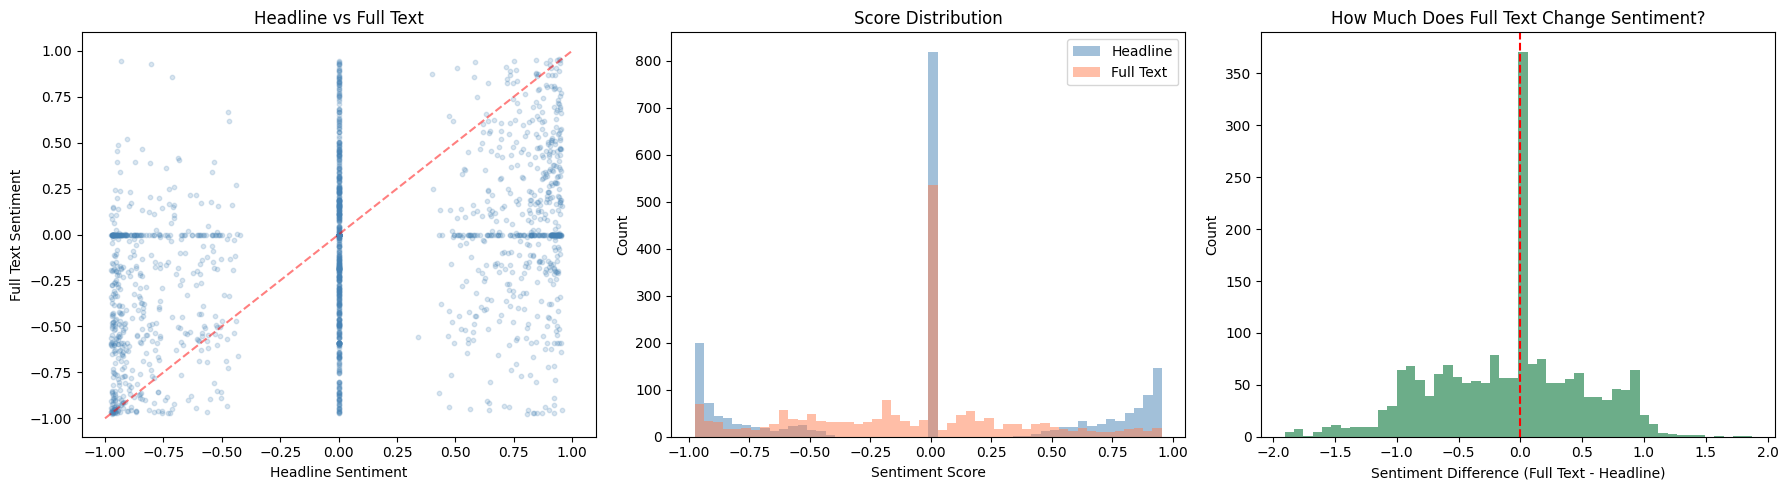

In [ ]:
from scipy.stats import pearsonr

# Correlation
corr, pval = pearsonr(
    df_scraped['finbert_compound'],
    df_scraped['fulltext_finbert_compound']
)

# Polarity agreement
headline_pos = (df_scraped['finbert_compound'] >= 0)
fulltext_pos = (df_scraped['fulltext_finbert_compound'] >= 0)
agreement = (headline_pos == fulltext_pos).mean() * 100

print("=" * 60)
print("HEADLINE vs FULL TEXT SENTIMENT COMPARISON")
print("=" * 60)
print(f"\nCorrelation:              {corr:.4f} (p={pval:.2e})")
print(f"Polarity Agreement:       {agreement:.1f}%")
print(f"Headline avg sentiment:   {df_scraped['finbert_compound'].mean():.4f}")
print(f"Full text avg sentiment:  {df_scraped['fulltext_finbert_compound'].mean():.4f}")

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1) Scatter plot
axes[0].scatter(
    df_scraped['finbert_compound'],
    df_scraped['fulltext_finbert_compound'],
    alpha=0.2, s=10, color='steelblue'
)
axes[0].plot([-1, 1], [-1, 1], 'r--', alpha=0.5)
axes[0].set_xlabel('Headline Sentiment')
axes[0].set_ylabel('Full Text Sentiment')
axes[0].set_title('Headline vs Full Text')

# 2) Distribution comparison
axes[1].hist(df_scraped['finbert_compound'], bins=50,
             alpha=0.5, label='Headline', color='steelblue')
axes[1].hist(df_scraped['fulltext_finbert_compound'], bins=50,
             alpha=0.5, label='Full Text', color='coral')
axes[1].set_xlabel('Sentiment Score')
axes[1].set_ylabel('Count')
axes[1].set_title('Score Distribution')
axes[1].legend()

# 3) Difference distribution
diff = df_scraped['fulltext_finbert_compound'] - df_scraped['finbert_compound']
axes[2].hist(diff, bins=50, color='seagreen', alpha=0.7)
axes[2].axvline(0, color='red', linestyle='--')
axes[2].set_xlabel('Sentiment Difference (Full Text - Headline)')
axes[2].set_ylabel('Count')
axes[2].set_title('How Much Does Full Text Change Sentiment?')

plt.tight_layout()
plt.savefig(f'{PROJECT_DIR}/results/headline_vs_fulltext.png',
            dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# Show examples where headline and full text sentiment differ most
df_scraped['sentiment_diff'] = abs(
    df_scraped['fulltext_finbert_compound'] - df_scraped['finbert_compound']
)

print("📊 TOP 5 HEADLINES WHERE FULL TEXT CHANGED SENTIMENT THE MOST:")
print("=" * 80)

top_diff = df_scraped.nlargest(5, 'sentiment_diff')
for _, row in top_diff.iterrows():
    print(f"\n📰 Headline: {row['Title'][:100]}")
    print(f"   Headline sentiment:  {row['finbert_compound']:.4f}")
    print(f"   Full text sentiment: {row['fulltext_finbert_compound']:.4f}")
    print(f"   Difference:          {row['sentiment_diff']:.4f}")
    print("-" * 80)

📊 TOP 5 HEADLINES WHERE FULL TEXT CHANGED SENTIMENT THE MOST:

📰 Headline: gdp : HDFC Bank pegs GDP growth higher at 7 . 3 % in FY19 on rural push
   Headline sentiment:  0.9542
   Full text sentiment: -0.9533
   Difference:          1.9075
--------------------------------------------------------------------------------

📰 Headline: Budget 2018 : Moody is happy with Modi , says 3 . 3 % fiscal deficit in Budget achievable
   Headline sentiment:  0.9236
   Full text sentiment: -0.9686
   Difference:          1.8922
--------------------------------------------------------------------------------

📰 Headline: Challenging year ahead for Indian economy , as trade deficit set to spiral despite healthy exports g
   Headline sentiment:  -0.9305
   Full text sentiment: 0.9421
   Difference:          1.8727
--------------------------------------------------------------------------------

📰 Headline: India GDP forecast : India GDP may turn positive at 1 . 3 per cent in December quarter : Report
  

In [ ]:
# Save everything
df_scraped.to_csv(
    f'{PROJECT_DIR}/data/extension_fulltext_sentiment.csv',
    index=False
)

# Save comparison summary
summary = {
    'Metric': [
        'Articles Scraped',
        'Correlation (Headline vs Full Text)',
        'Polarity Agreement %',
        'Headline Avg Sentiment',
        'Full Text Avg Sentiment'
    ],
    'Value': [
        len(df_scraped),
        round(corr, 4),
        round(agreement, 1),
        round(df_scraped['finbert_compound'].mean(), 4),
        round(df_scraped['fulltext_finbert_compound'].mean(), 4)
    ]
}
pd.DataFrame(summary).to_csv(
    f'{PROJECT_DIR}/results/extension_summary.csv',
    index=False
)

print("✅ All extension results saved!")
print(f"📁 Data: {PROJECT_DIR}/data/extension_fulltext_sentiment.csv")
print(f"📁 Summary: {PROJECT_DIR}/results/extension_summary.csv")

✅ All extension results saved!
📁 Data: /content/drive/MyDrive/PolicySentimentProject/data/extension_fulltext_sentiment.csv
📁 Summary: /content/drive/MyDrive/PolicySentimentProject/results/extension_summary.csv
